<a href="https://colab.research.google.com/github/kauefs/ML/blob/%40/notebooks/RegressionAutoML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

[![ƊⱭȾɅViƧi🧿Ƞ](https://img.shields.io/badge/ƊⱭȾɅViƧi🧿Ƞ&trade;-0065FF?style=plastic)](https://datavision.one/)
[![GitHub](  https://img.shields.io/badge/-000000?logo=github&logoColor=FFFFFF)](https://github.com/kauefs/)
[![Medium](  https://img.shields.io/badge/-000000?logo=medium&logoColor=FFFFFF)](https://medium.com/@kauefs)
[![LinkedIn](https://img.shields.io/badge/-0077B5?logo=linkedin&logoColor=FFFFFF)](https://www.linkedin.com/in/kauefs/)
[![Python](  https://img.shields.io/badge/-3-4584B6?logo=python&logoColor=FFDE57&labelColor=4584B6&color=646464)](https://www.python.org/)
[![License]( https://img.shields.io/badge/Apache--2.0-D22128?style=flat&logo=apache&logoColor=CB2138&label=License&labelColor=6D6E71&color=D22128)](https://www.apache.org/licenses/LICENSE-2.0)

<a href=https://sigmoidal.ai/><img alt=SigMoidal src=https://raw.githubusercontent.com/carlosfab/escola-data-science/master/img/novo_logo_bg_escuro.png width=50%>

<img src=https://raw.githubusercontent.com/carlosfab/escola-data-science/master/img/eds.png></a>

![2024.12.13  ](https://img.shields.io/badge/2024.12.13-000000)

In [ ]:
!date

Wed Jan  8 03:17:23 AM UTC 2025


---
# AutoML

<center>
    <img src=https://pycaret.org/wp-content/uploads/2020/03/Divi93_43.png>
</center>

## Regression Project

Regression**:** SuperVised Machine Learning Module used for estimating the relationships between a Dependent Variable **(**OutCome Variable or Target**)** and one or more Independent Variables **(**Features or Predictors or CoVariates**)**, aiming to predict continuous values.

Objective**:** **Health Insurance Cost Prediction**.

<center>
    <img src=https://images.unsplash.com/photo-1579684385127-1ef15d508118>
</center>

Health insurance costs in the United States have been a significant concern for individuals **&** families. Premiums for employer**-**sponsored health insurance have risen steadily, with the average family premium exceeding **$**23**,**000 in 2023. This increase outpaces wage growth **&** inflation, making it increasingly difficult for many to afford coverage. High deductibles **&** out**-**of**-**pocket costs further burden individuals, leaving them vulnerable to financial hardship in the event of unexpected medical expenses. These rising costs have significant implications for individual **&** family finances, as well as the overall health **&** well**-**being of the population.

1. Load [Data](https://www.kaggle.com/annetxuhealth-insurance-cost-prediction);
2. Data Analysis **(**BiVariate Analysis **&** MultiVariate Analysis**)**;
3. Machine Learning solution using PyCaret for Regression.
*  Documentation **&** StoryTelling **&** Article with Code.

Types of Variables**:**
* Categorical**:** `sex`, `smoker`,   `region`;
* Numerical**:**   `age`,    `bmi`, `children`, `charges`;
    - Target**:**                               `charges`.

References**:**
* [Regression Analysis for Insurance Data](https://www.kaggle.com/code/syedmalizaidi/regression-analysis-for-insurance-data)
* [Health Insurance Price Prediction](https://www.kaggle.com/code/mdzainulabdeen/health-insurance-price-prediction)
* [PyCaret Regression Tutorial](https://colab.research.google.com/github/pycaret/pycaret/blob/master/tutorials/Tutorial%20-%20Regression.ipynb)

In [ ]:
# Installs:
%pip install -q pycaret explainerdashboard

In [ ]:
# @title SetUp
# Libraries:
import       numpy                   as   np
import      pandas                   as   pd
import     seaborn                   as   sns
import                                    sys
import statsmodels.api               as   sm
import  matplotlib.pyplot            as   plt
import  matplotlib.cm                as   cm
from    matplotlib.colors          import Normalize
from       sklearn.model_selection import train_test_split
from       sklearn.preprocessing   import StandardScaler
from       pycaret.datasets        import get_data
from       pycaret.regression      import    *
from       explainerdashboard      import RegressionExplainer, InlineExplainer, ExplainerDashboard, dashboards
# Configurations:
print('System Ready: Python –'  ,         sys.version)
%matplotlib inline
%config     InlineBackend.figure_format= 'svg'
# %config     InlineBackend.print_figure_kwargs={'bbox_inches':None}
# %precision 2
pd.options.plotting.matplotlib.register_converters=True
pd.set_option('display.max.columns',               None)
plt.rcParams[      'font.family']      =                                        'sans-serif'
sns.set_theme(context='notebook', style='whitegrid', palette='colorblind', font='sans-serif', font_scale=1.15, color_codes=True, rc={'grid.color':'1','grid.linestyle':':'})

System Ready: Python – 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]


In [ ]:
# @title DataSet
data=get_data('insurance')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# DataSet Info:
data=data.drop_duplicates()
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [ ]:
# Statistical Summary:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Numeric Columns:
data.select_dtypes(include=['number']).columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [ ]:
# Categorical Columns:
data.select_dtypes(exclude=['number']).columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [ ]:
# Quantity & Representativity of Missing Values:
(data.isnull().sum()).sort_values(ascending=False).head(60)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Categorical Variables Unique Values:
data['sex'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
# Entries per Gender:
data['sex'].value_counts(ascending=True)

,count
sex,
female,662
male,675


In [ ]:
data['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
# Entries per Smoker:
data['smoker'].value_counts(ascending=True)

,count
smoker,
yes,274
no,1063


In [ ]:
data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
# Entries per Region:
data['region'].value_counts(ascending=True)

,count
region,
northwest,324
northeast,324
southwest,325
southeast,364


In [ ]:
# Numerical Variables Unique Values:
data['age'].unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39])

In [ ]:
data['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [ ]:
# Entries per Children:
data['children'].value_counts(ascending=True)

,count
children,
5,18
4,25
3,157
2,240
1,324
0,573


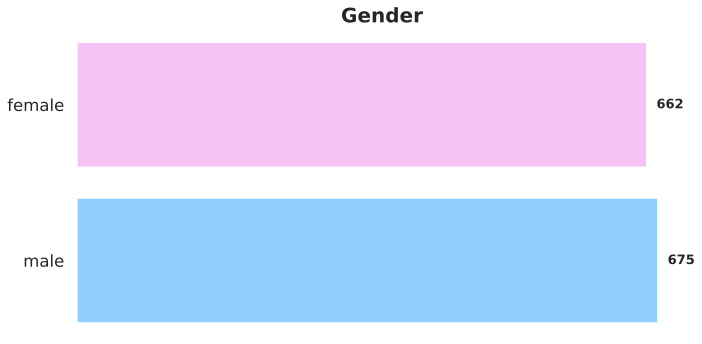

In [ ]:
# Gender Horizontal Bar Chart:
fig, ax=  plt.subplots(figsize=[10,5], tight_layout=True)
palette=['#90CFFF','#F4C2F4']#(252, 198, 188),( 22, 259, 230)
bars=plt.barh(y=data['sex'].value_counts().index, width=data['sex'].value_counts().values, color=palette)
plt.bar_label(bars, labels=data['sex'].value_counts().values, label_type='edge', fontsize=13, padding=10, fontweight='semibold')
ax.set_title('Gender', fontsize=20, fontweight='bold')
ax.set(ylabel=None)
for spine in ['left','top','bottom','right']:ax.spines[spine].set_visible(False)
plt.gca().axes.get_yaxis().set_visible(True )
plt.gca().axes.get_xaxis().set_visible(False)
plt.tick_params(axis        ='both',
                which       ='both',
                left        = False,
                labelleft   =  True,
                labelsize   ='large')
plt.show()

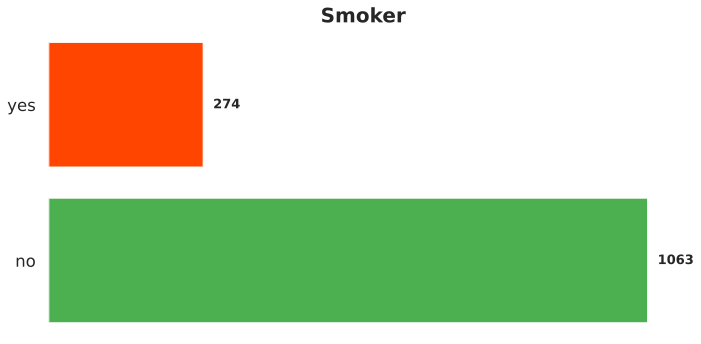

In [ ]:
# Smoker Horizontal Bar Chart:
fig, ax=  plt.subplots(figsize=[10,5], tight_layout=True)
palette=['#4CAF50','#FF4500']
bars=plt.barh(y=data['smoker'].value_counts().index, width=data['smoker'].value_counts().values, color=palette)
plt.bar_label(bars, labels=data['smoker'].value_counts().values, label_type='edge', fontsize=13, padding=10, fontweight='semibold')
ax.set_title('Smoker', fontsize=20, fontweight='bold')
ax.set(ylabel=None)
for spine in ['left','top','bottom','right']:ax.spines[spine].set_visible(False)
plt.gca().axes.get_yaxis().set_visible(True )
plt.gca().axes.get_xaxis().set_visible(False)
plt.tick_params(axis        ='both',
                which       ='both',
                left        = False,
                labelleft   =  True,
                labelsize   ='large')
plt.show()

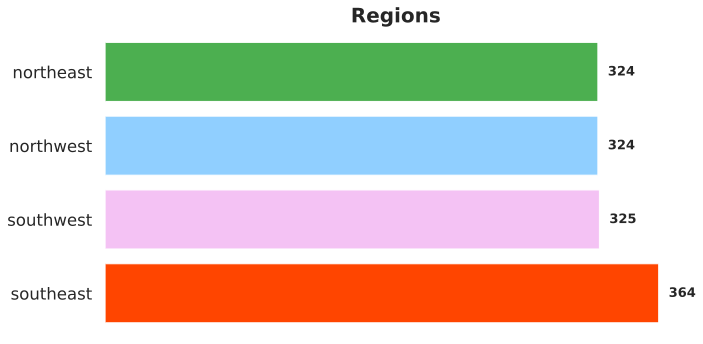

In [ ]:
# Region Horizontal Bar Chart:
fig, ax=  plt.subplots(figsize=[10,5], tight_layout=True)
palette=['#FF4500','#F4C2F4','#90CFFF','#4CAF50']
bars=plt.barh(y=data['region'].value_counts().index, width=data['region'].value_counts().values, color=palette)
plt.bar_label(bars, labels=data['region'].value_counts().values, label_type='edge', fontsize=13, padding=10, fontweight='semibold')
ax.set_title('Regions', fontsize=20, fontweight='bold')
ax.set(ylabel=None)
for spine in ['left','top','bottom','right']:ax.spines[spine].set_visible(False)
plt.gca().axes.get_yaxis().set_visible(True )
plt.gca().axes.get_xaxis().set_visible(False)
plt.tick_params(axis        ='both',
                which       ='both',
                left        = False,
                labelleft   =  True,
                labelsize   ='large')
plt.show()

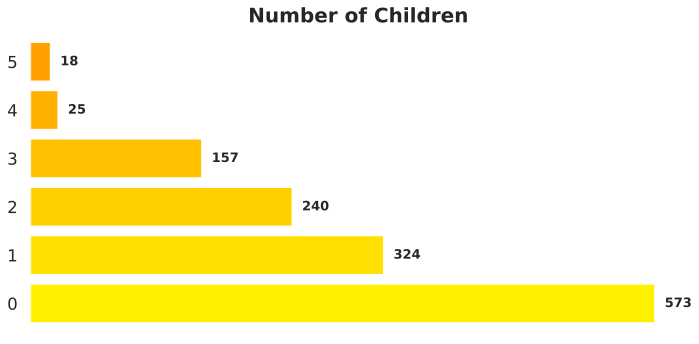

In [ ]:
# Children Horizontal Bar Chart:
fig, ax=  plt.subplots(figsize=[10,5], tight_layout=True)
palette=['#FFF000','#FFE000','#FFD000','#FFC000','#FFB000','#FFA000']
bars=plt.barh(y=data['children'].value_counts().index, width=data['children'].value_counts().values, color=palette)
plt.bar_label(bars, labels=data['children'].value_counts().values, label_type='edge', fontsize=13, padding=10, fontweight='semibold')
ax.set_title('Number of Children', fontsize=20, fontweight='bold')
ax.set(ylabel=None)
for spine in ['left','top','bottom','right']:ax.spines[spine].set_visible(False)
plt.gca().axes.get_yaxis().set_visible(True )
plt.gca().axes.get_xaxis().set_visible(False)
plt.tick_params(axis        ='both',
                which       ='both',
                left        = False,
                labelleft   =  True,
                labelsize   ='large')
plt.show()

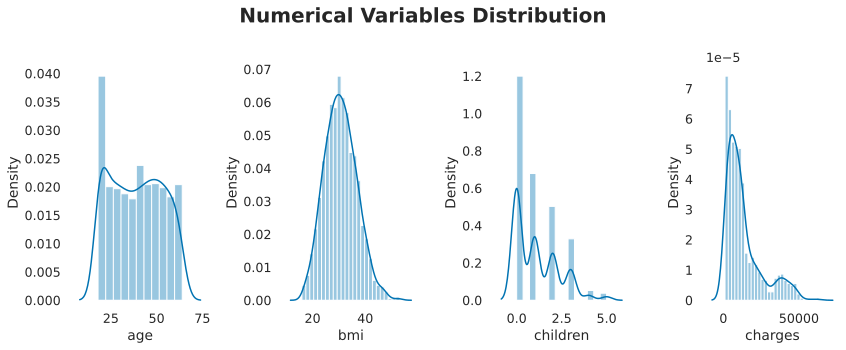

In [ ]:
# @title Numerical Variables Distribution
plt.figure(figsize=(12,5))
plt.suptitle('Numerical Variables Distribution', fontsize=20, fontweight='bold')
plt.subplot(1,4,1)
sns.distplot(data[     'age'])
plt.subplot(1,4,2)
sns.distplot(data[     'bmi'])
plt.subplot(1,4,3)
sns.distplot(data['children'])
plt.subplot(1,4,4)
sns.distplot(data[ 'charges'])
sns.despine(left=True, bottom=True, right=True, top=True)
plt.tight_layout(pad=1.15)
plt.show()

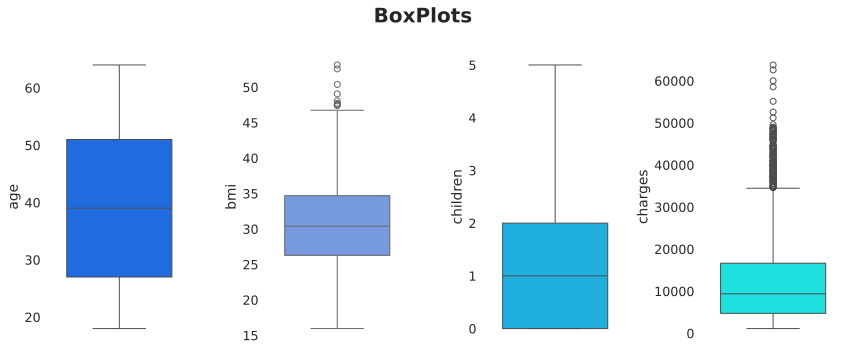

In [ ]:
# BoxPlots:
plt.figure(figsize=(12,5))
plt.suptitle('BoxPlots', fontsize=20,  fontweight='bold')
plt.subplot(1,4,1)
sns.boxplot(data[     'age'] ,           color='#0065FF')
plt.subplot(1,4,2)
sns.boxplot(data[     'bmi'] ,           color='#6595EE')
plt.subplot(1,4,3)
sns.boxplot(data['children'] ,           color='#00BFFF')
plt.subplot(1,4,4)
sns.boxplot(data[ 'charges'] ,           color='#00FFFF')
sns.despine(left=True, bottom=True, right=True, top=True)
plt.tight_layout(pad=1.15)
plt.show()

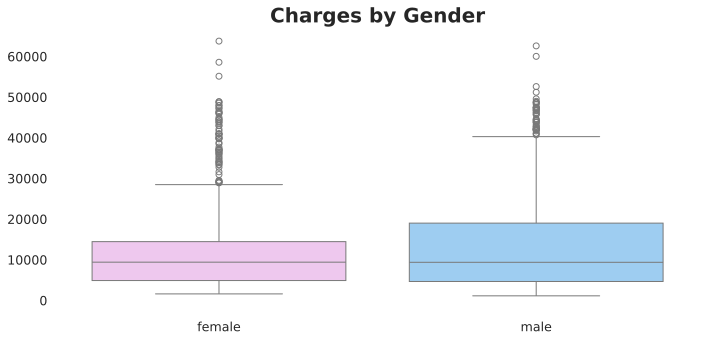

In [ ]:
# Charges by Gender:
palette=['#F4C2F4','#90CFFF']
plt.subplots(figsize=(10, 5))
sns.boxplot(y='charges', x='sex', data=data, hue='sex', palette=palette)
plt.title('Charges by Gender',  fontsize=20, fontweight='bold')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.tight_layout(pad=1.15)
plt.show(    )

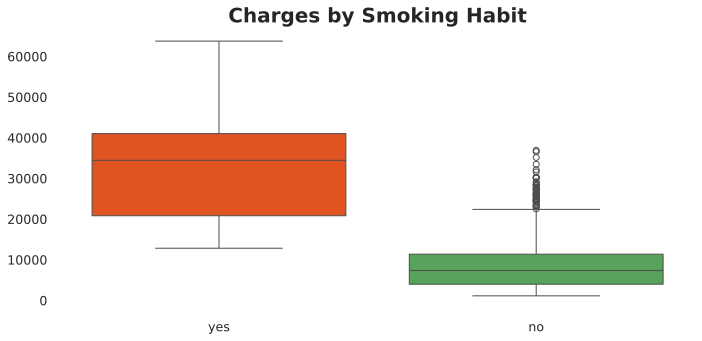

In [ ]:
# Charges by Smoking Habit:
palette=['#FF4500','#4CAF50']
plt.subplots(figsize=(10, 5))
sns.boxplot(y='charges', x='smoker' ,   data=data, hue='smoker', palette=palette)
plt.title('Charges by Smoking Habit', fontsize=20, fontweight='bold')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.tight_layout(pad=1.15)
plt.show(    )

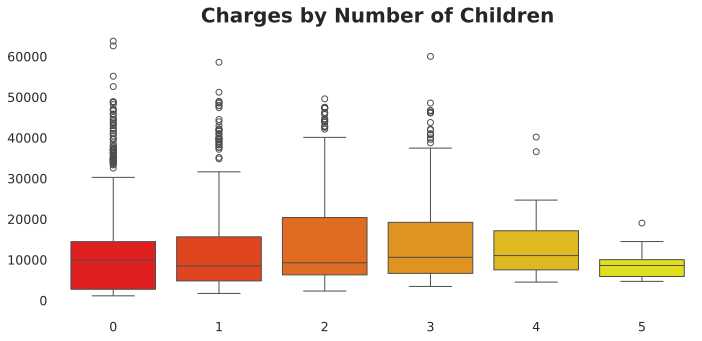

In [ ]:
# Charges by Number of Children:
plt.subplots(figsize=(10, 5))
sns.boxplot( y='charges', x='children', data=data, hue='children', palette='autumn')
plt.title(     'Charges by Number of Children',    fontsize=20, fontweight='bold'  )
plt.legend('')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.tight_layout(pad=1.15)
plt.show(    )

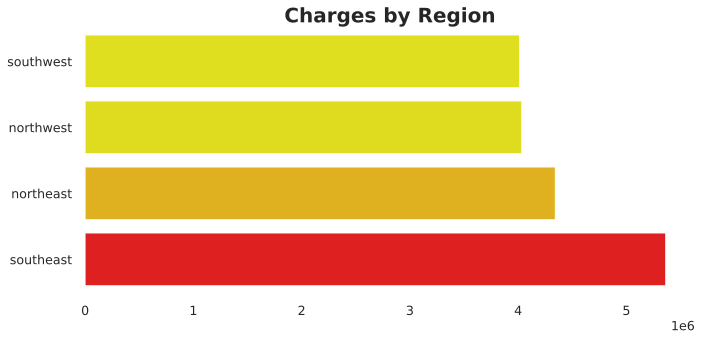

In [ ]:
# Charges by Region:
price=data['charges'].groupby(data['region']).sum().sort_values(ascending=True)
plt.subplots(figsize=(10, 5))
sns.barplot(y=price.index, x=price.values, hue=price.values, palette='autumn_r')
plt.title( 'Charges by Region', fontsize=20, fontweight='bold')
plt.legend('')
plt.ylabel('')
plt.xlabel('')
plt.box(False)
plt.tight_layout(pad=1.15)
plt.show(    )

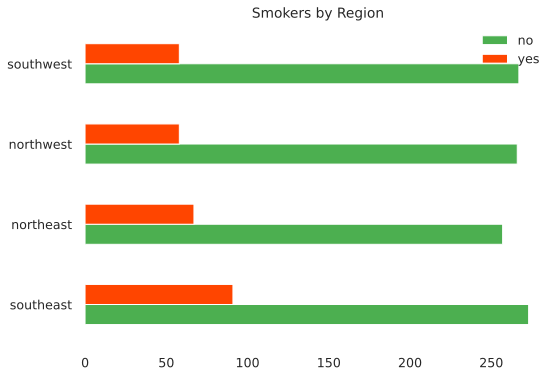

In [ ]:
# Smokers By Region:
palette=['#4CAF50','#FF4500']
RegionalSmokers=data.groupby('region')['smoker'].value_counts().unstack().fillna(0)
RegionalSmokers=RegionalSmokers.sort_values(by='yes', ascending=False)
RegionalSmokers.plot(kind='barh', color=palette)
plt.xlabel('')
plt.ylabel('')
plt.title( 'Smokers by Region')
plt.legend(loc='best')
plt.box(False)
plt.tight_layout(pad=1.15)
plt.show()

In [ ]:
RegionalSmokers['yes'].sort_values(ascending=True)

,yes
region,
northwest,58
southwest,58
northeast,67
southeast,91


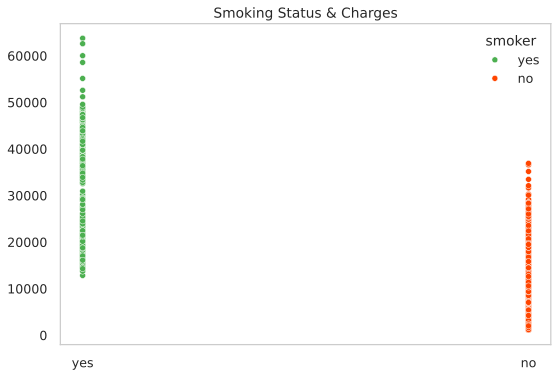

In [ ]:
# Smoking & Charges:
palette=['#4CAF50','#FF4500']
sns.scatterplot(data=data, y='charges', x='smoker', hue='smoker', palette=palette)
plt.title('Smoking Status & Charges')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout(pad=1.15)
plt.show(    )

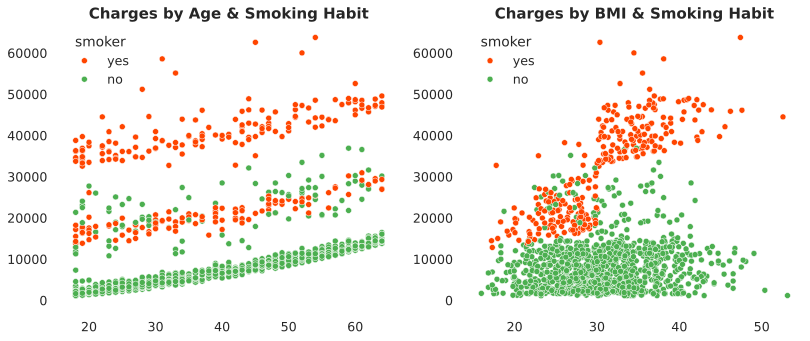

In [ ]:
# Charges by Age & Smoking Habit & BMI & Smoking Habits:
palette=['#FF4500','#4CAF50']
fig, axs  =plt.subplots(1, 2, figsize=(11.5, 5))
sns.scatterplot(data=data, y='charges', x='age', hue='smoker', palette=palette, ax=axs[0])
axs[0].set_title( 'Charges by Age & Smoking Habit',   fontsize=15,      fontweight='bold')
axs[0].set_xlabel('')
axs[0].set_ylabel('')
sns.scatterplot(data=data, y='charges', x='bmi', hue='smoker', palette=palette, ax=axs[1])
axs[1].set_title( 'Charges by BMI & Smoking Habit',   fontsize=15,      fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('')
sns.despine(top=True, left=True, bottom=True, right=True)
plt.tight_layout(pad=1.15)
plt.show()

In [ ]:
# @title OutLiers Treatment
bmiQ1 =data['bmi'].quantile(.25)
bmiQ3 =data['bmi'].quantile(.75)
bmiIQR=bmiQ3-bmiQ1
print('BMI         IQR:  {:,.2f}'.format(bmiIQR))
superiorBMI=bmiQ3 + 1.5 * bmiIQR
inferiorBMI=bmiQ1 - 1.5 * bmiIQR
print('Upper Bound BMI: {:,.2f}'.format(superiorBMI),
    '\nLower Bound BMI: {:,.2f}'.format(inferiorBMI))

BMI         IQR:  8.41
Upper Bound BMI: 47.32 
Lower Bound BMI: 13.67


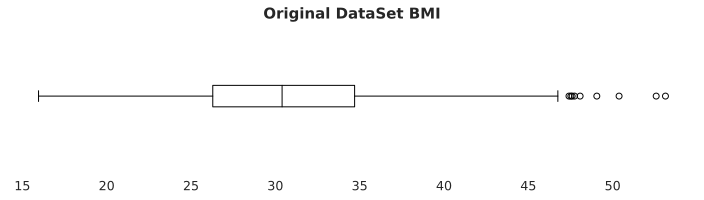

DataSet has 1337 entries 
of which 9 are above 47.32, 
representing 0.67% of the DataSet.


In [ ]:
# BoxPlot:
fig, ax = plt.subplots(figsize=(10, 3) , tight_layout=True)
data['bmi'].plot(kind='box', vert=False, color='#000000'  )
ax.set_title('Original DataSet BMI', fontsize=15, fontweight='bold')
for spine in ['left','top','bottom','right']:ax.spines[spine].set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.tick_params(axis   =  'both',
                which  =  'both',
                bottom =  False)
plt.show()
print('DataSet has {} entries'
      .format(data.shape[0]),
      '\nof which {} are above {:,.2f},'
      .format( len(data[data['bmi'] > superiorBMI]), superiorBMI),
      '\nrepresenting {:,.2f}% of the DataSet.'
      .format((len(data[data['bmi'] > superiorBMI])/data.shape[0])*100))

In [ ]:
# OutLiers Treatment:
cQ1 =data['charges'].quantile(.25)
cQ3 =data['charges'].quantile(.75)
cIQR=cQ3-cQ1
print('Charges         IQR:  {:,.2f}'.format(cIQR))
superiorC=cQ3 + 1.5 * cIQR
inferiorC=cQ1 - 1.5 * cIQR
print('Upper Bound Charges:  {:,.2f}'.format(superiorC),
    '\nLower Bound Charges: {:,.2f}'.format( inferiorC))

Charges         IQR:  11,911.37
Upper Bound Charges:  34,524.78 
Lower Bound Charges: -13,120.72


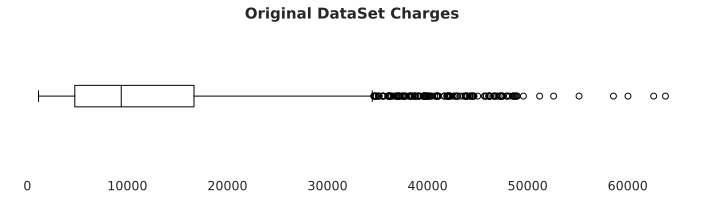

DataSet has 1337 entries 
of which 139 are above 34,524.78, 
representing 10.40% of the DataSet.


In [ ]:
# BoxPlot:
fig, ax = plt.subplots(figsize=(10, 3),tight_layout=   True  )
data['charges'].plot(kind='box',  vert=False, color='#000000')
ax.set_title('Original DataSet Charges', fontsize=15, fontweight='bold')
for spine in ['left','top','bottom','right']:ax.spines[spine].set_visible(False)
plt.gca().axes.get_yaxis().set_visible(False)
plt.tick_params(axis   =  'both',
                which  =  'both',
                bottom =  False)
plt.show()
print('DataSet has {} entries'
      .format(data.shape[0]),
      '\nof which {} are above {:,.2f},'
      .format( len(data[data['charges'] > superiorC]), superiorC),
      '\nrepresenting {:,.2f}% of the DataSet.'
      .format((len(data[data['charges'] > superiorC])/data.shape[0])*100))

In [ ]:
# DataSet Cleaning:
clean=data.copy()
# clean[    'bmi']=np.where(clean[    'bmi']>superiorBMI, superiorBMI,
#                  np.where(clean[    'bmi']<inferiorBMI, inferiorBMI,  clean[    'bmi']))
# clean['charges']=np.where(clean['charges']>superiorC  , superiorC  ,
#                  np.where(clean['charges']<inferiorC  , inferiorC  ,  clean['charges']))
clean.drop(clean[clean[    'bmi'] > superiorBMI].index, axis=0, inplace=True)#   45.
clean.drop(clean[clean['charges'] > superiorC  ].index, axis=0, inplace=True)#35000.
print('Original: {}'.format(   data.shape),
      '\n     New: {}'.format(clean.shape))

Original: (1337, 7) 
     New: (1192, 7)


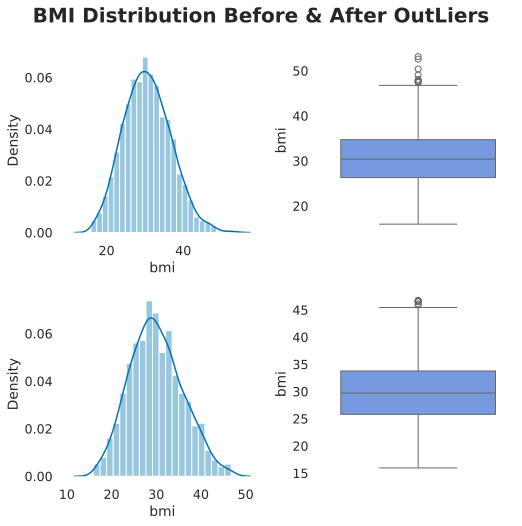

In [ ]:
# @title New Distribution
plt.figure(figsize=(7.5,7.5))
plt.suptitle(      'BMI Distribution Before & After OutLiers', fontsize=20, fontweight='bold')
plt.subplot(2,2,1)
sns.distplot(data[ 'bmi'])
plt.subplot(2,2,2)
sns.boxplot(data[  'bmi'], color='#6595EE')
plt.subplot(2,2,3)
sns.distplot(clean['bmi'])
plt.subplot(2,2,4)
sns.boxplot(clean[ 'bmi'], color='#6595EE')
sns.despine(left=True, bottom=True, right=True, top=True)
plt.tight_layout(pad=1.15)
plt.show()

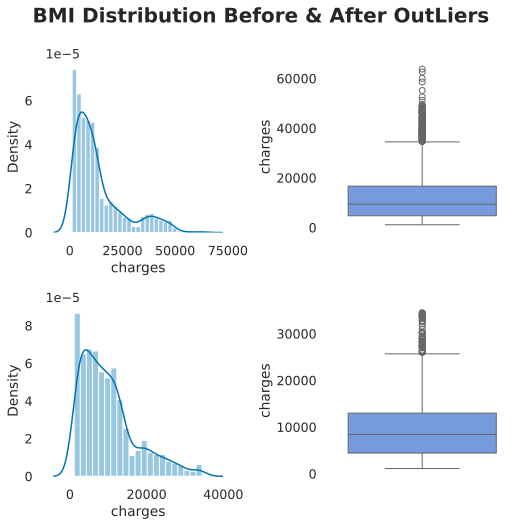

In [ ]:
plt.figure(figsize=(7.5,7.5))
plt.suptitle(      'Charges Distribution Before & After OutLiers', fontsize=20, fontweight='bold')
plt.subplot(2,2,1)
sns.distplot(data[ 'charges'])
plt.subplot(2,2,2)
sns.boxplot(data[  'charges'], color='#6595EE')
plt.subplot(2,2,3)
sns.distplot(clean['charges'])
plt.subplot(2,2,4)
sns.boxplot(clean[ 'charges'], color='#6595EE')
sns.despine(left=True, bottom=True, right=True, top=True)
plt.tight_layout(pad=1.15)
plt.show()

In [ ]:
# Encoding Categorical Variables:
encodedData=pd.get_dummies(data, columns=['sex','smoker','region'])
encodedOverView=encodedData
encodedOverView#.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,False,True,True,False,False,True,False,False
1334,18,31.920,0,2205.98080,True,False,True,False,True,False,False,False
1335,18,36.850,0,1629.83350,True,False,True,False,False,False,True,False
1336,21,25.800,0,2007.94500,True,False,True,False,False,False,False,True


In [ ]:
num_cols=['age','bmi','children','charges']
# Standardizing Numerical Features:
scaler  =StandardScaler()
encodedData[num_cols]=scaler.fit_transform(encodedData[num_cols])
standardOverView=encodedData#.head(15)
standardOverView

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,0.297857,True,False,False,True,False,False,False,True
1,-1.511647,0.509422,-0.079442,-0.954381,False,True,True,False,False,False,True,False
2,-0.799350,0.383155,1.580143,-0.729373,False,True,True,False,False,False,True,False
3,-0.443201,-1.305052,-0.909234,0.719104,False,True,True,False,False,True,False,False
4,-0.514431,-0.292456,-0.909234,-0.777499,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0.050269,1.580143,-0.221263,False,True,True,False,False,True,False,False
1334,-1.511647,0.206053,-0.909234,-0.914695,True,False,True,False,True,False,False,False
1335,-1.511647,1.014490,-0.909234,-0.962287,True,False,True,False,False,False,True,False
1336,-1.297958,-0.797524,-0.909234,-0.931054,True,False,True,False,False,False,False,True


In [ ]:
# Correlation Matrix:
cm=standardOverView.corr()
cm

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,0.109344,0.041536,0.298308,0.019814,-0.019814,0.025587,-0.025587,0.001868,0.001495,-0.012311,0.009415
bmi,0.109344,1.000000,0.012755,0.198401,-0.046397,0.046397,-0.003746,0.003746,-0.138178,-0.136138,0.270057,-0.006211
children,0.041536,0.012755,1.000000,0.067389,-0.017848,0.017848,-0.007331,0.007331,-0.023202,0.026044,-0.023492,0.021538
charges,0.298308,0.198401,0.067389,1.000000,-0.058044,0.058044,-0.787234,0.787234,0.005945,-0.038695,0.073578,-0.043637
sex_female,0.019814,-0.046397,-0.017848,-0.058044,1.000000,-1.000000,0.076596,-0.076596,0.002008,0.012482,-0.017578,0.003767
sex_male,-0.019814,0.046397,0.017848,0.058044,-1.000000,1.000000,-0.076596,0.076596,-0.002008,-0.012482,0.017578,-0.003767
smoker_no,0.025587,-0.003746,-0.007331,-0.787234,0.076596,-0.076596,1.000000,-1.000000,-0.002597,0.036321,-0.068282,0.037168
smoker_yes,-0.025587,0.003746,0.007331,0.787234,-0.076596,0.076596,-1.000000,1.000000,0.002597,-0.036321,0.068282,-0.037168
region_northeast,0.001868,-0.138178,-0.023202,0.005945,0.002008,-0.002008,-0.002597,0.002597,1.000000,-0.319842,-0.345909,-0.320493
region_northwest,0.001495,-0.136138,0.026044,-0.038695,0.012482,-0.012482,0.036321,-0.036321,-0.319842,1.000000,-0.345909,-0.320493


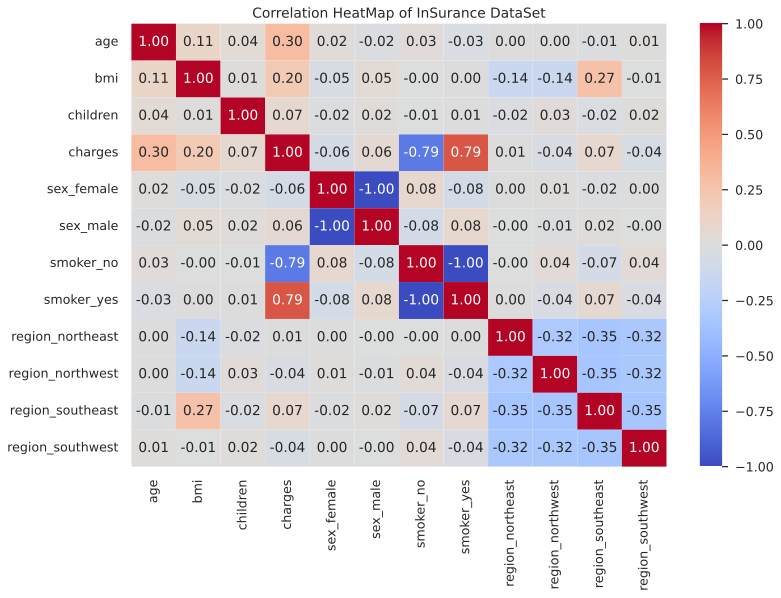

In [ ]:
# HeatMap:
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation HeatMap of InSurance DataSet'  )
plt.show()

In [ ]:
# Convert Categorical Variables to Dummy Variables:
encod=pd.get_dummies(data, drop_first=True)
# Convert Boolean Columns to Integers:
encod=encod.astype(int)
# Ensure All Data is Numerical & Properly Formatted:
print(encod.dtypes)

age                 int64
bmi                 int64
children            int64
charges             int64
sex_male            int64
smoker_yes          int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object


In [ ]:
# Regression Analysis:
# Independent Variables (including 'smoker_yes'):
x=encod.drop('charges', axis=1)
# Add Constant to the Model:
x=sm.add_constant(x)
# Dependent Variable:
y=encod['charges']
# Regression Model
model=sm.OLS(y, x).fit()
# print model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     499.9
Date:                Wed, 08 Jan 2025   Prob (F-statistic):               0.00
Time:                        03:18:09   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.174e+04    975.698  

In [ ]:
# SetUp: RegressionExperiment
setup=setup(data, target='charges', session_id    =    123 ,
           #   normalize=   True, normalize_method='minmax',
            )

,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1337, 7)"
4,Transformed data shape,"(1337, 10)"
5,Transformed train set shape,"(935, 10)"
6,Transformed test set shape,"(402, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


In [ ]:
# Compare Models:
best=compare_models()
print('\nBest Model:', best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2731.3004,23301502.0637,4776.8135,0.8345,0.4436,0.3173,0.3360
lightgbm,Light Gradient Boosting Machine,3026.1250,25842447.5092,5036.3401,0.8146,0.5699,0.3790,0.2610
rf,Random Forest Regressor,2851.8300,25765011.0123,5037.2734,0.8134,0.4706,0.3394,0.3970
ada,AdaBoost Regressor,4189.5747,27907520.1110,5247.4565,0.8010,0.5945,0.6603,0.1350
et,Extra Trees Regressor,2844.5638,29174755.5109,5355.9828,0.7908,0.4774,0.3190,0.3260
xgboost,Extreme Gradient Boosting,3327.8060,31728352.0000,5576.6492,0.7718,0.5954,0.4359,0.2120
ridge,Ridge Regression,4372.9897,38815954.9519,6189.1711,0.7270,0.5719,0.4414,0.1580
br,Bayesian Ridge,4366.5889,38816041.7229,6189.0874,0.7269,0.5730,0.4402,0.0890
llar,Lasso Least Angle Regression,4358.7294,38812237.3157,6188.6755,0.7269,0.5754,0.4388,0.0880
lar,Least Angle Regression,4358.5824,38815148.9096,6188.9138,0.7269,0.5759,0.4387,0.0860


Processing:   0%|          | 0/81 [00:00<?, ?it/s]


Best Model: GradientBoostingRegressor(random_state=123)


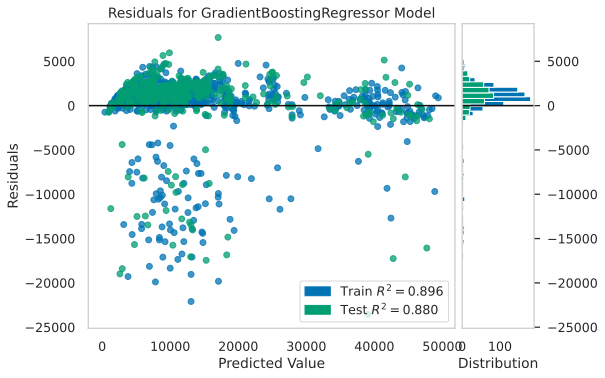

In [ ]:
# Residuals:
plot_model(best, plot='residuals')

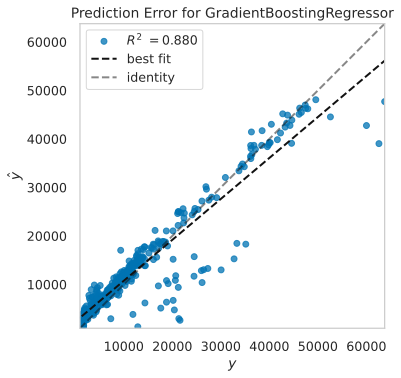

In [ ]:
# Error:
plot_model(best, plot='error')

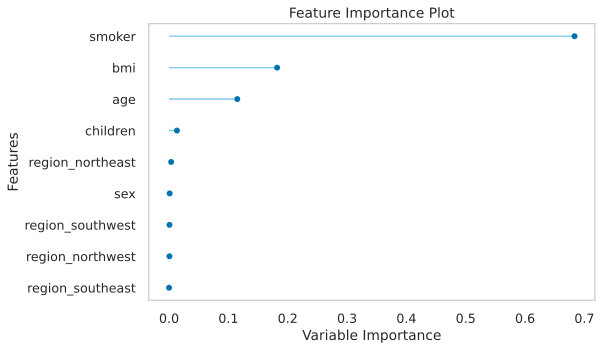

In [ ]:
# Feature Importance:
plot_model(best, plot='feature')

In [ ]:
# Analyze Model:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Tunning:
tuned=tune_model(best)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3553.8320,36052084.9677,6004.3388,0.7907,0.8696,0.4238
1,3551.6923,33217862.6684,5763.4940,0.7994,0.6964,0.4374
2,3449.3611,30804097.1351,5550.1439,0.7587,0.6919,0.5897
3,3438.7220,27053937.5181,5201.3400,0.7450,0.6157,0.6193
4,3703.0175,41338105.0326,6429.4716,0.7070,0.7615,0.4898
5,3795.2635,32654636.4383,5714.4235,0.6011,0.5988,0.4806
6,3963.8015,36719097.5916,6059.6285,0.7394,0.6327,0.4412
7,3842.0079,36697705.4924,6057.8631,0.8142,0.8974,0.4598
8,2571.7836,17530360.9207,4186.9274,0.8980,0.4361,0.3835


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
# LeaderBoard:
lb=get_leaderboard()
lb

Processing:   0%|          | 0/22 [00:00<?, ?it/s]

,Model Name,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
Index,,,,,,,,
0,Linear Regression,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4358.5824,3.881515e+07,6188.9138,0.7269,0.5759,0.4387
1,Lasso Regression,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4358.7271,3.881220e+07,6188.6724,0.7269,0.5754,0.4388
2,Ridge Regression,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4372.9897,3.881595e+07,6189.1711,0.7270,0.5719,0.4414
3,Elastic Net,"(TransformerWrapper(include=['age', 'bmi', 'ch...",7461.2048,9.078632e+07,9477.8202,0.3719,0.7479,0.9538
4,Least Angle Regression,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4358.5824,3.881515e+07,6188.9138,0.7269,0.5759,0.4387
5,Lasso Least Angle Regression,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4358.7294,3.881224e+07,6188.6755,0.7269,0.5754,0.4388
6,Orthogonal Matching Pursuit,"(TransformerWrapper(include=['age', 'bmi', 'ch...",9278.9175,1.361108e+08,11603.9863,0.0585,0.8903,1.1918
7,Bayesian Ridge,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4366.5889,3.881604e+07,6189.0874,0.7269,0.5730,0.4402
8,Passive Aggressive Regressor,"(TransformerWrapper(include=['age', 'bmi', 'ch...",4153.4622,6.623199e+07,8039.1675,0.5478,0.5240,0.2193


In [ ]:
# Best Model Based on MAE:
lb.sort_values(by='MAE', ascending=True)['Model'].iloc[0]

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['age', 'bmi', 'children'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['sex', 'smoker', 'region'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerWrapper(include=['sex', 'smoker'],
                                    transfor...
                                                                         'data_type': dtype('O'),
                                                                         'mapping': female    0
male      1
NaN      -1
dtype: int64},
                                                                        {'col': 'smoker',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': no     0
yes    1
NaN   -1
dtype: int64}]))),
                ('onehot_encoding',
                 TransformerWrapper(include=['region'],
                                    transformer=OneHotEncoder(cols=['region'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ['trained_model', GradientBoostingRegressor(random_state=123)]])

In [ ]:
# Linear Regression Model:
create_model('lr', fit_intercept=False)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4797.9671,42890894.1151,6549.1140,0.7510,0.5572,0.5067
1,4241.9333,35979283.5766,5998.2734,0.7827,0.5902,0.4178
2,3789.5282,29223361.5594,5405.8636,0.7711,0.6812,0.4159
3,3785.0165,25831658.7881,5082.4855,0.7565,0.4677,0.5102
4,4779.0537,48269198.5550,6947.6038,0.6578,0.6720,0.4312
5,3756.0182,29547883.8757,5435.7965,0.6391,0.6424,0.3705
6,4474.6328,46927877.8625,6850.3925,0.6670,0.5059,0.3966
7,4705.6404,46934540.3188,6850.8788,0.7624,0.5252,0.4248
8,4213.1787,32125410.3774,5667.9282,0.8131,0.5029,0.4623


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

LinearRegression(fit_intercept=False, n_jobs=-1)

In [ ]:
# Best Model Based on Cross-Validation Metrics:
automl()

GradientBoostingRegressor(random_state=123)

In [ ]:
# Save Model:
save_model(tuned,'BestPyCaretRegressorPipeLine')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['age', 'bmi', 'children'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['sex', 'smoker', 'region'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['sex', 'smoker'],
                                     transfor...
                                                                          'data_type': dtype('O'),
                                                                          'mapping': female    0
 male      1
 NaN      -1
 dtype: int64},
                                                                         {'col': 'smoker',
                                                                          'data_type': dtype(

In [ ]:
# Load Model:
model=load_model('BestPyCaretRegressorPipeLine')
print(model)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['age', 'bmi', 'children'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['sex', 'smoker', 'region'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerWrapper(include=['sex', 'smoker...
                                                                         'data_type': dtype('O'),
                                                                         'mapping': female    0
male      1
NaN      -1
dtype: int64},
                                                                        {'col': 'smoker',
                                                                         'data_type': dtype(

In [ ]:
# @title Predictions
new=clean.copy()
new.drop('charges', axis=1, inplace=True)
new#.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [ ]:
# Predictions:
# predict_model(best)
# predictions=predict_model(best, data=data)
pred=predict_model(model, data=new)
pred

,age,sex,bmi,children,smoker,region,prediction_label
0,19,female,27.900000,0,yes,southwest,18571.201397
1,18,male,33.770000,1,no,southeast,3662.612224
2,28,male,33.000000,3,no,southeast,6824.938686
3,33,male,22.705000,0,no,northwest,6833.738477
4,32,male,28.879999,0,no,northwest,3981.049413
...,...,...,...,...,...,...,...
1333,50,male,30.969999,3,no,northwest,11895.494866
1334,18,female,31.920000,0,no,northeast,3124.779296
1335,18,female,36.849998,0,no,southeast,3041.108367
1336,21,female,25.799999,0,no,southwest,2849.330796


In [ ]:
#  XGBoost Model:
xgb=create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3368.8484,33398174.0000,5779.1152,0.8061,0.5796,0.4140
1,3290.9863,31670076.0000,5627.6172,0.8087,0.6092,0.4179
2,3277.2529,27559264.0000,5249.6919,0.7841,0.6716,0.6581
3,3027.4924,23110716.0000,4807.3608,0.7822,0.5326,0.5155
4,3797.4717,44344480.0000,6659.1650,0.6857,0.7341,0.4823
5,3506.4133,29616618.0000,5442.1152,0.6382,0.5133,0.4144
6,3561.2170,34961724.0000,5912.8438,0.7519,0.5543,0.3438
7,3645.5962,39361780.0000,6273.8965,0.8008,0.7931,0.4113
8,2162.9463,14134612.0000,3759.6025,0.9178,0.3973,0.3049


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

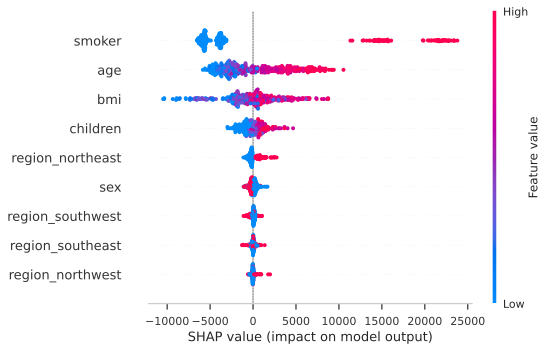

In [ ]:
# InterPret Summary:
interpret_model(xgb, plot='summary')

In [ ]:
#  Reason            Plot     for   Observation 1:
interpret_model(xgb, plot='reason', observation=1)

In [ ]:
# DashBoard:
# dashboard(model, display_format='inline')#'dash','external'
X, x, Y, y = train_test_split(new, clean['charges'], test_size=.2)
explainer=RegressionExplainer(model, x, y)
ExplainerDashboard( explainer, simple=True).run()

Generating self.shap_explainer = shap.KernelExplainer(model, X)...
Building ExplainerDashboard..
Detected google colab environment, setting mode='external'
Calculating shap values...


  0%|          | 0/239 [00:00<?, ?it/s]

Calculating predictions...
Calculating residuals...
Calculating absolute residuals...
Generating layout...
Calculating dependencies...
Reminder: you can store the explainer (including calculated dependencies) with explainer.dump('explainer.joblib') and reload with e.g. ClassifierExplainer.from_file('explainer.joblib')
Registering callbacks...
Starting ExplainerDashboard on http://172.28.0.12:8050
You can terminate the dashboard with ExplainerDashboard.terminate(8050)


<IPython.core.display.Javascript object>

Dash app running on:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
explainer.preds

array([ 3812.31088357, 20474.16953229, 10962.28759771, 13763.80358845,
       14508.1936907 , 14916.6082644 ,  7685.79345296, 12753.61303608,
        7845.8556691 , 11895.49486574,  2762.08223016, 29791.49133945,
       11709.19892678,  5192.86935271, 15291.1907375 , 10345.14720858,
       11653.2968756 , 10169.65819545, 10494.00506786,  8615.44228865,
        4774.42847024,  9563.43478601, 10276.75804652,  4776.81786264,
       14574.62347817, 11739.13064475,  3009.7054002 ,  7288.031838  ,
        5401.08570334,  7652.20940175,  6584.72429253,  5878.89748674,
        2563.68098826, 13649.36352516, 19375.70113969,  7514.07425952,
        2961.83002663, 30156.33946465,  8233.82557875, 12193.81087059,
        7913.32695773,  8314.97657717,  8279.11982822,  7678.83298783,
        8939.14412828,  4040.04477279, 12292.78081577,  9432.66359225,
       10128.00018944,  6319.22751395, 18817.65552397, 11920.54381777,
       11852.50471928,  8028.64326094,  4343.89660924,  7956.4752991 ,
      